In [2]:
import sys
sys.path.append("..")

In [3]:
from src.data import load_data, clean_data

ds = load_data()
print(f"Loaded: {len(ds)} pairs")

clean_ds = clean_data(ds)
print(f"After cleaning: {len(clean_ds)} pairs")
print(f"Removed: {len(ds) - len(clean_ds)} pairs")

Loaded: 10000 pairs
After cleaning: 9760 pairs
Removed: 240 pairs


Exploratory Data Analysis - Raw Dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

raw_data = ds.to_pandas()

raw_data["en"] = raw_data["translation"].apply(lambda x: x["en"])
raw_data["de"] = raw_data["translation"].apply(lambda x: x["de"])

raw_data["en_length"] = raw_data["en"].apply(lambda x: len(x.split()))
raw_data["de_length"] = raw_data["de"].apply(lambda x: len(x.split()))
raw_data["length_ratio"] = raw_data["de_length"] / raw_data["en_length"]

print("=== Dataset Overview ===")
print(f"Total sentence pairs: {len(raw_data)}")
print(f"\n=== EN Sentence Length (words) ===")
print(raw_data["en_length"].describe().round(2))
print(f"\n=== DE Sentence Length (words) ===")
print(raw_data["de_length"].describe().round(2))
print(f"\n=== DE/EN Length Ratio ===")
print(raw_data["length_ratio"].describe().round(2))

print(f"\n=== Sample Sentence Pairs ===")
for i in range(3):
    print(f"\nEN: {raw_data['en'][i]}")
    print(f"DE: {raw_data['de'][i]}")

=== Dataset Overview ===
Total sentence pairs: 10000

=== EN Sentence Length (words) ===
count    10000.00
mean        25.10
std         15.27
min          1.00
25%         14.00
50%         22.00
75%         33.00
max        207.00
Name: en_length, dtype: float64

=== DE Sentence Length (words) ===
count    10000.00
mean        23.33
std         14.08
min          1.00
25%         13.00
50%         21.00
75%         30.25
max        180.00
Name: de_length, dtype: float64

=== DE/EN Length Ratio ===
count    10000.00
mean         0.95
std          0.25
min          0.12
25%          0.83
50%          0.93
75%          1.03
max         10.00
Name: length_ratio, dtype: float64

=== Sample Sentence Pairs ===

EN: There are some parallels but the Commissioner who helped me early on in this case, and my efforts, have been unable to persuade UK customs to act justly.
DE: Es gibt zwar einige Parallelen, aber weder der Kommissar, der mir frühzeitig bei diesem Fall behilflich war, noch meine ei

In [5]:
en_vocab = set(" ".join(raw_data["en"]).split())
de_vocab = set(" ".join(raw_data["de"]).split())

print(f"=== Vocabulary ===")
print(f"EN unique words: {len(en_vocab)}")
print(f"DE unique words: {len(de_vocab)}")

empty_en = raw_data[raw_data["en_length"] == 0]
empty_de = raw_data[raw_data["de_length"] == 0]
very_short = raw_data[(raw_data["en_length"] < 3) | (raw_data["de_length"] < 3)]
very_long = raw_data[(raw_data["en_length"] > 80) | (raw_data["de_length"] > 80)]
duplicates = raw_data[raw_data["en"].duplicated()]

print(f"\n=== Data Quality ===")
print(f"Empty EN sentences: {len(empty_en)}")
print(f"Empty DE sentences: {len(empty_de)}")
print(f"Very short pairs (<3 words): {len(very_short)}")
print(f"Very long pairs (>80 words): {len(very_long)}")
print(f"Duplicate EN sentences: {len(duplicates)}")

if len(very_short) > 0:
    print(f"\n=== Very Short Examples ===")
    for _, row in very_short.head(5).iterrows():
        print(f"EN: {row['en']}")
        print(f"DE: {row['de']}\n")

=== Vocabulary ===
EN unique words: 21445
DE unique words: 31348

=== Data Quality ===
Empty EN sentences: 0
Empty DE sentences: 0
Very short pairs (<3 words): 128
Very long pairs (>80 words): 60
Duplicate EN sentences: 117

=== Very Short Examples ===
EN:    .
DE:    .

EN: .
DE: .

EN: (Applause)
DE: (Beifall)

EN: Thank you very much!
DE: Vielen Dank!

EN: Why 2004?
DE: Warum 2004?



Exploratory Data-Analysis - Cleaned Dataset

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = clean_ds.to_pandas()

data["en"] = data["translation"].apply(lambda x: x["en"])
data["de"] = data["translation"].apply(lambda x: x["de"])

data["en_length"] = data["en"].apply(lambda x: len(x.split()))
data["de_length"] = data["de"].apply(lambda x: len(x.split()))
data["length_ratio"] = data["de_length"] / data["en_length"]

print("=== Dataset Overview ===")
print(f"Total sentence pairs: {len(data)}")
print(f"\n=== EN Sentence Length (words) ===")
print(data["en_length"].describe().round(2))
print(f"\n=== DE Sentence Length (words) ===")
print(data["de_length"].describe().round(2))
print(f"\n=== DE/EN Length Ratio ===")
print(data["length_ratio"].describe().round(2))

print(f"\n=== Sample Sentence Pairs ===")
for i in range(3):
    print(f"\nEN: {data['en'][i]}")
    print(f"DE: {data['de'][i]}")

=== Dataset Overview ===
Total sentence pairs: 9760

=== EN Sentence Length (words) ===
count    9760.00
mean       25.42
std        14.66
min         3.00
25%        15.00
50%        23.00
75%        33.00
max       118.00
Name: en_length, dtype: float64

=== DE Sentence Length (words) ===
count    9760.00
mean       23.65
std        13.55
min         3.00
25%        14.00
50%        21.00
75%        31.00
max       115.00
Name: de_length, dtype: float64

=== DE/EN Length Ratio ===
count    9760.00
mean        0.95
std         0.18
min         0.50
25%         0.83
50%         0.93
75%         1.03
max         2.00
Name: length_ratio, dtype: float64

=== Sample Sentence Pairs ===

EN: There are some parallels but the Commissioner who helped me early on in this case, and my efforts, have been unable to persuade UK customs to act justly.
DE: Es gibt zwar einige Parallelen, aber weder der Kommissar, der mir frühzeitig bei diesem Fall behilflich war, noch meine eigenen Bemühungen konnten 

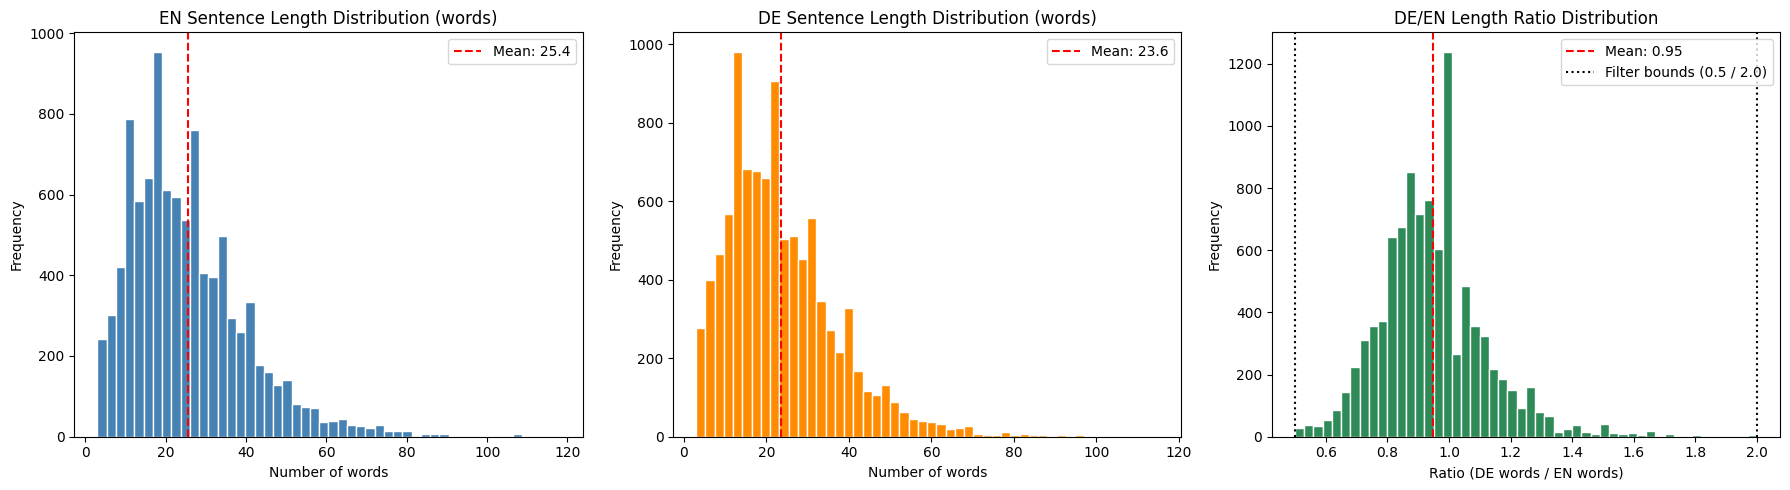

Plot saved to eda_plots.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# EN sentence length histogram
axes[0].hist(data["en_length"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("EN Sentence Length Distribution (words)")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Frequency")
axes[0].axvline(data["en_length"].mean(), color="red", linestyle="--", label=f'Mean: {data["en_length"].mean():.1f}')
axes[0].legend()

# DE sentence length histogram
axes[1].hist(data["de_length"], bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("DE Sentence Length Distribution (words)")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Frequency")
axes[1].axvline(data["de_length"].mean(), color="red", linestyle="--", label=f'Mean: {data["de_length"].mean():.1f}')
axes[1].legend()

# DE/EN length ratio histogram
axes[2].hist(data["length_ratio"], bins=50, color="seagreen", edgecolor="white")
axes[2].set_title("DE/EN Length Ratio Distribution")
axes[2].set_xlabel("Ratio (DE words / EN words)")
axes[2].set_ylabel("Frequency")
axes[2].axvline(data["length_ratio"].mean(), color="red", linestyle="--", label=f'Mean: {data["length_ratio"].mean():.2f}')
axes[2].axvline(0.5, color="black", linestyle=":", label="Filter bounds (0.5 / 2.0)")
axes[2].axvline(2.0, color="black", linestyle=":")
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to eda_plots.png")

In [6]:
en_vocab = set(" ".join(data["en"]).split())
de_vocab = set(" ".join(data["de"]).split())

print(f"=== Vocabulary ===")
print(f"EN unique words: {len(en_vocab)}")
print(f"DE unique words: {len(de_vocab)}")

empty_en = data[data["en_length"] == 0]
empty_de = data[data["de_length"] == 0]
very_short = data[(data["en_length"] < 3) | (data["de_length"] < 3)]
very_long = data[(data["en_length"] > 80) | (data["de_length"] > 80)]
duplicates = data[data["en"].duplicated()]

print(f"\n=== Data Quality ===")
print(f"Empty EN sentences: {len(empty_en)}")
print(f"Empty DE sentences: {len(empty_de)}")
print(f"Very short pairs (<3 words): {len(very_short)}")
print(f"Very long pairs (>80 words): {len(very_long)}")
print(f"Duplicate EN sentences: {len(duplicates)}")

if len(very_short) > 0:
    print(f"\n=== Very Short Examples ===")
    for _, row in very_short.head(5).iterrows():
        print(f"EN: {row['en']}")
        print(f"DE: {row['de']}\n")

=== Vocabulary ===
EN unique words: 21235
DE unique words: 31093

=== Data Quality ===
Empty EN sentences: 0
Empty DE sentences: 0
Very short pairs (<3 words): 0
Very long pairs (>80 words): 52
Duplicate EN sentences: 0


/home/mlt_ml4/machine-learning-project/.venv/lib/python3.10/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
/home/mlt_ml4/machine-learning-project/.venv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:4114: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


=== Tokenized Sequence Length Statistics (subword tokens) ===

EN token lengths:
  Mean:    30.5
  Median:  27.0
  Max:     128
  >128 tokens: 0 sequences truncated

DE token lengths:
  Mean:    31.3
  Median:  28.0
  Max:     128
  >128 tokens: 0 sequences truncated

Note: Filtering used word counts via .split() before tokenization.
The 128-token limit covers the vast majority of sentences while keeping memory usage manageable.


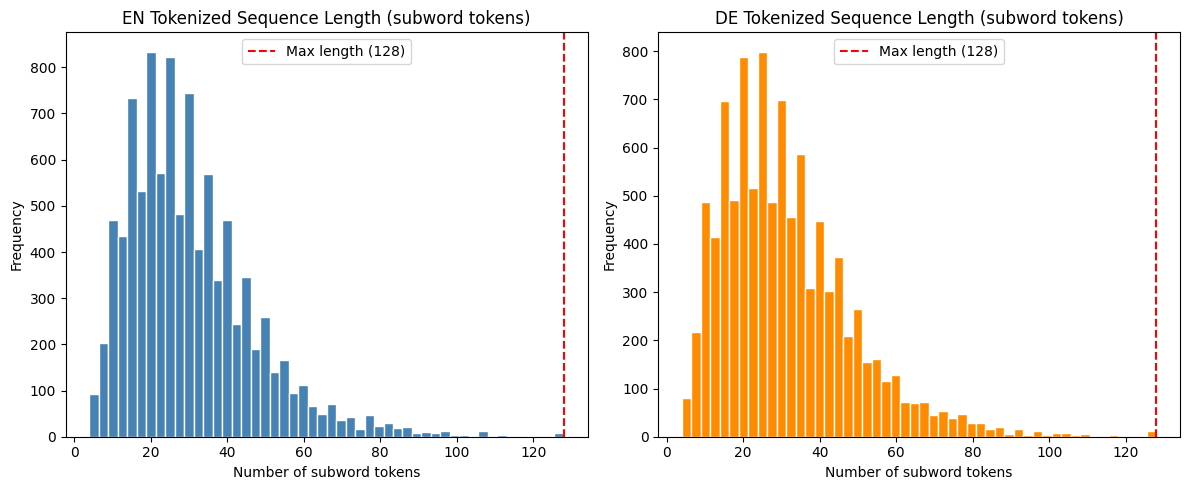

Plot saved to tokenized_length_plots.png


In [7]:
from src.preprocessing import preprocess_function
import numpy as np

tokenized_ds = preprocess_function(clean_ds)
en_token_lengths = np.array([len(ids) for ids in tokenized_ds["input_ids"]])
de_token_lengths = np.array([len(ids) for ids in tokenized_ds["labels"]])

print("=== Tokenized Sequence Length Statistics (subword tokens) ===")
print(f"\nEN token lengths:")
print(f"  Mean:    {en_token_lengths.mean():.1f}")
print(f"  Median:  {np.median(en_token_lengths):.1f}")
print(f"  Max:     {en_token_lengths.max()}")
print(f"  >128 tokens: {(en_token_lengths > 128).sum()} sequences truncated")

print(f"\nDE token lengths:")
print(f"  Mean:    {de_token_lengths.mean():.1f}")
print(f"  Median:  {np.median(de_token_lengths):.1f}")
print(f"  Max:     {de_token_lengths.max()}")
print(f"  >128 tokens: {(de_token_lengths > 128).sum()} sequences truncated")

print(f"\nNote: Filtering used word counts via .split() before tokenization.")
print(f"The 128-token limit covers the vast majority of sentences while keeping memory usage manageable.")

# Plot token length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(en_token_lengths, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("EN Tokenized Sequence Length (subword tokens)")
axes[0].set_xlabel("Number of subword tokens")
axes[0].set_ylabel("Frequency")
axes[0].axvline(128, color="red", linestyle="--", label="Max length (128)")
axes[0].legend()

axes[1].hist(de_token_lengths, bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("DE Tokenized Sequence Length (subword tokens)")
axes[1].set_xlabel("Number of subword tokens")
axes[1].set_ylabel("Frequency")
axes[1].axvline(128, color="red", linestyle="--", label="Max length (128)")
axes[1].legend()

plt.tight_layout()
plt.savefig("tokenized_length_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to tokenized_length_plots.png")